<a href="https://colab.research.google.com/github/chuy-zip/COMPUTER_VISION_LAB7/blob/main/TASK3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 3
### Integrantes
* Sergio Orellana 221122
* Rodrigo Mansilla 22611
* Ricardo Chuy 221007

In [18]:
import kagglehub
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import plotly
import sklearn
from PIL import Image
from tensorflow.keras import layers
import time
import os
import pandas as pd


In [19]:
# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


### Dataset

### División

In [20]:
# verificar distribución de clases
from collections import Counter

# Proporciones
def print_proportions(labels, name):
    total = len(labels)
    counts = Counter(labels)
    print(f"\nProporciones en {name} (Total: {total}):")
    for label, count in counts.items():
        print(f"{label}: {count} ({count/total:.2%})")

try:
    print_proportions(train_labels, "Entrenamiento")
    print_proportions(val_labels, "Validación")
    print_proportions(test_labels, "Prueba")
except NameError as e:
    print(f"Error: {e}. Por favor, asegúrate de ejecutar primero la celda de división del dataset (2c4af60d).")


Proporciones en Entrenamiento (Total: 4099):
PNEUMONIA: 2991 (72.97%)
NORMAL: 1108 (27.03%)

Proporciones en Validación (Total: 878):
NORMAL: 237 (26.99%)
PNEUMONIA: 641 (73.01%)

Proporciones en Prueba (Total: 879):
PNEUMONIA: 641 (72.92%)
NORMAL: 238 (27.08%)


In [21]:
import os
from sklearn.model_selection import train_test_split

data_dir = os.path.join(path, 'chest_xray')

all_filepaths = []
all_labels = []

for split in ['train', 'test', 'val']:
    split_path = os.path.join(data_dir, split)
    if not os.path.exists(split_path): continue

    for label in ['NORMAL', 'PNEUMONIA']:
        label_path = os.path.join(split_path, label)
        if not os.path.exists(label_path): continue
        images = [f for f in os.listdir(label_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        for img in images:
            all_filepaths.append(os.path.join(label_path, img))
            all_labels.append(label)

print(f'Total images found: {len(all_filepaths)}')

#  70% train, 30%  (val + test)
train_files, temp_files, train_labels, temp_labels = train_test_split(
    all_filepaths, all_labels, test_size=0.3, random_state=42, stratify=all_labels
)

# Split 15% val, 15% test
val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

print(f'Train set: {len(train_files)} images')
print(f'Validation set: {len(val_files)} images')
print(f'Test set: {len(test_files)} images')

Total images found: 5856
Train set: 4099 images
Validation set: 878 images
Test set: 879 images


In [22]:
from collections import Counter
print(Counter(train_labels))
print(Counter(val_labels))
print(Counter(test_labels))

Counter({'PNEUMONIA': 2991, 'NORMAL': 1108})
Counter({'PNEUMONIA': 641, 'NORMAL': 237})
Counter({'PNEUMONIA': 641, 'NORMAL': 238})


El dataset original presentaba una división de train/val/test con las clases `PNEUMONIA` y `NORMAL`, con desbalance.

### Justificación de la estratificación

Sin estratificación, una división aleatoria podría producir proporciones diferentes entre splits. En contexto médico esto es relevante,  un test con más
casos `NORMAL` de los reales inflaría artificialmente la accuracy, ocultando  el verdadero rendimiento del modelo. El error más peligroso en este dominio es la predicciòn de falsos negativos.

La división se realizó en dos pasos con train_test_split porque la funcion de división es binaria y resulta dos conjuntos.


La proporción se mantiene consistente (~73% / ~27%) en los tres conjuntos, confirmando que la estratificación preservó la distribución original.

### Data Augmentation

Unique Sizes found: {(1628, 1283), (1360, 848), (1136, 760), (1692, 1221), (1136, 528), (1368, 1120), (1542, 963), (880, 536), (936, 792), (1104, 728)} ... (showing first few)
All sizes the same? False
Unique Channels: {2, 3} (2 = Grayscale, 3 = RGB)
Pixel Range: Min 0, Max 255

Ejemplos de clase NORMAL:


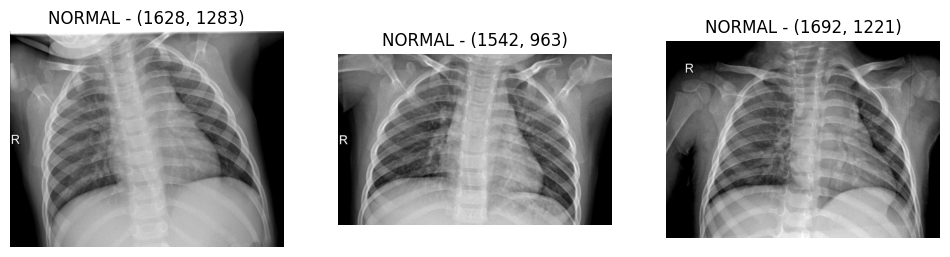

Ejemplos de clase PNEUMONIA:


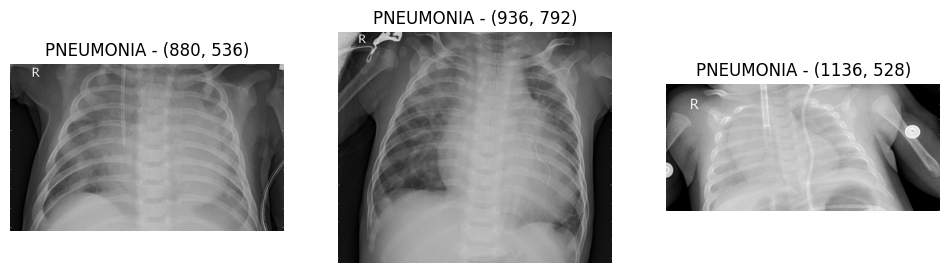

In [23]:


# 1. Verificar Dimensiones, Canales, y rangos de Px
sizes = []
channels = []
pixel_min = []
pixel_max = []

# muestra de  100 imgs
for i in range(min(100, len(train_files))):
    with Image.open(train_files[i]) as img:
        sizes.append(img.size)
        img_array = np.array(img)
        channels.append(len(img_array.shape))
        pixel_min.append(img_array.min())
        pixel_max.append(img_array.max())

print(f"Unique Sizes found: {set(sizes[:10])} ... (showing first few)")
print(f"All sizes the same? {len(set(sizes)) == 1}")
print(f"Unique Channels: {set(channels)} (2 = Grayscale, 3 = RGB)")
print(f"Pixel Range: Min {min(pixel_min)}, Max {max(pixel_max)}")

# Visualización de ejemplos
def plot_samples(files, labels, class_name, n=3):
    class_files = [f for f, l in zip(files, labels) if l == class_name]
    plt.figure(figsize=(12, 4))
    for i in range(n):
        plt.subplot(1, n, i+1)
        img = Image.open(class_files[i])
        plt.imshow(img, cmap='gray')
        plt.title(f"{class_name} - {img.size}")
        plt.axis('off')
    plt.show()

print("\nEjemplos de clase NORMAL:")
plot_samples(train_files, train_labels, 'NORMAL')

print("Ejemplos de clase PNEUMONIA:")
plot_samples(train_files, train_labels, 'PNEUMONIA')


Las muestras muestran:
- Los tamaños son variables, no hay imagenes del mismo tamaño.

- Los canales estan mezclados, hay imagenes RGRB y grayscale.

- El rango es `[0,255]`

- Las imágenes tienen variación real de zoom, posición del paciente, y brillo.



### Data augmentation Train

In [24]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def imagenet_normalize(img):
    mean = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
    std = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)
    return (img - mean) / std

def imagenet_denormalize(img):
    mean = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
    std = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)
    return img * std + mean

train_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.027, fill_mode="reflect"),
    layers.RandomZoom(0.1, fill_mode="reflect"),
    layers.RandomBrightness(0.1, value_range=(0, 1)),
    layers.RandomContrast(0.1)
])

# Pipeline Train
def process_train(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = train_augmentation(img, training=True)
    img = tf.clip_by_value(img, 0.0, 1.0)   # importante
    img = imagenet_normalize(img)
    label_idx = tf.where(tf.equal(label, 'PNEUMONIA'), 1, 0)
    return img, label_idx


def process_train(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = train_augmentation(img, training=True)
    img = imagenet_normalize(img)
    label_idx = 1 if label == 'PNEUMONIA' else 0
    return img, label_idx

def process_val_test(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = imagenet_normalize(img)
    label_idx = tf.where(tf.equal(label, 'PNEUMONIA'), 1, 0)
    return img, label_idx

# Create Datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_files, train_labels)).map(process_train, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((val_files, val_labels)).map(process_val_test, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((test_files, test_labels)).map(process_val_test, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Batch size:", BATCH_SIZE)

Batch size: 32


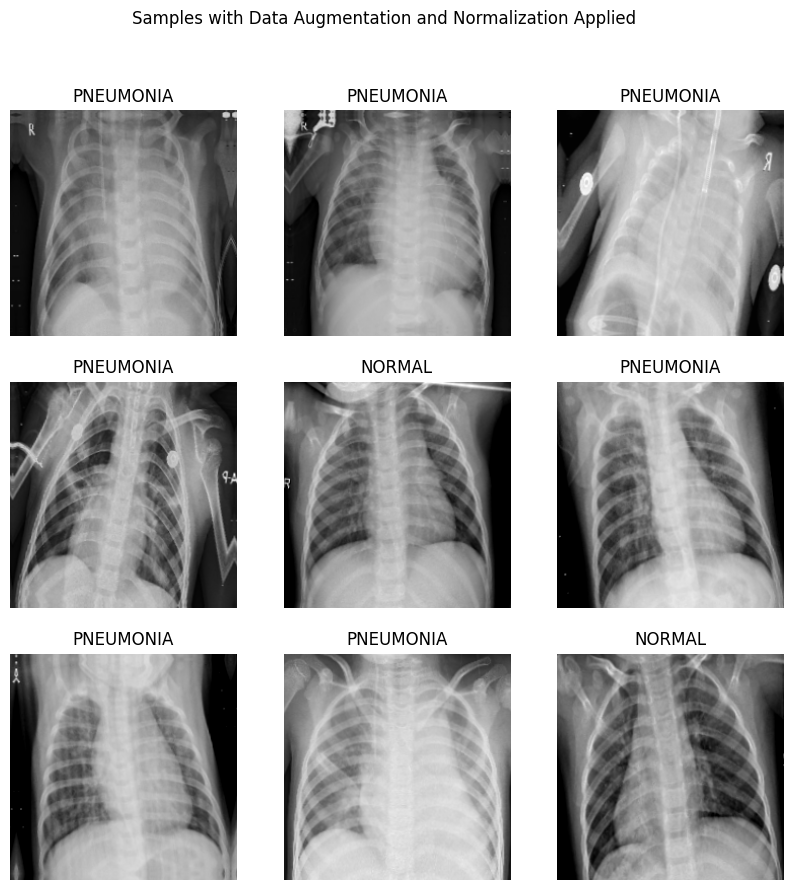

In [25]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(min(9, images.shape[0])):
        ax = plt.subplot(3, 3, i + 1)
        img_to_show = imagenet_denormalize(images[i])
        img_to_show = tf.clip_by_value(img_to_show, 0.0, 1.0)
        plt.imshow(img_to_show.numpy())
        plt.title("PNEUMONIA" if labels[i].numpy() == 1 else "NORMAL")
        plt.axis("off")

plt.suptitle("Samples with Data Augmentation and Normalization Applied")
plt.show()

Val y test miden rendimiento real. Si se usa data augmentation en  val/test, se está evaluando el modelo sobre imágenes artificialmente modificadas que no existen en producción. Lo que se intenta hacer con un pipeline diferente en `train`, es que el modela aprenda diferentes representaciones de casos posibles, diferentes a los que se usan en validación y pruebas.

La única transformación que es apropiada en val/test es normalización y resize, porque esas no son artificiales y representan mejor escenarios de prueba. Son solamente preprocesamiento necesario para que el modelo reciba el input en el formato correcto.

### Carga de Modelos
- EfficientNet
-  MobileNetV2

### Decisiones

| Hiperparámetro | Valor | Justificación |
|---|---:|---|
| Loss | Binary Focal Crossentropy | Adecuada para desbalance de clases,  obliga al modelo a enfocarse más en casos difíciles o minoritarios. |
| Optimizador | AdamW | Su regularización desacoplada  generaliza mejor que Adam estándar cuando se quiere controlar sobreajuste. |
| Learning Rate | 1e-4 |Permite ajustar la cabeza del modelo sin destruir representaciones preentrenadas. |
| Batch size | 32 | Es un punto intermedio útil entre estabilidad del gradiente, eficiencia computacional y regularización .  |
| Epochs máximas | 30–50 | Es un rango suficiente para permitir convergencia sin asumir de entrada que más épocas mejoran el desempeño. |
| Early Stopping | monitor=`val_loss`, patience=5 | `val_loss` captura mejor la calidad probabilística del modelo y detecta sobreajuste antes de que accuracy lo refleje. |

In [26]:

# 1. EfficientNetB0
base_efficientnet = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_efficientnet.trainable = False

# 2. MobileNetV2
base_mobilenet = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_mobilenet.trainable = False  #

print("EfficientNetB0 and MobileNetV2 loaded successfully.")

EfficientNetB0 and MobileNetV2 loaded successfully.


Se congelaron las capas convolucionales base porque ya contienen características visuales generales aprendidas en preentrenamiento y, dado que el dataset es relativamente limitado, actualizarlas desde el inicio aumentaría el riesgo de sobreajuste sin aportar una mejora proporcional.

## Entrenamiento




In [27]:
def build_model(base_model, name):
    inputs = layers.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inputs, outputs, name=name)

    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=1e-4),
        loss=keras.losses.BinaryFocalCrossentropy(),
        metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')]
    )
    return model

model_effnet = build_model(base_efficientnet, "EfficientNet_Pneumonia")
model_mobilenet = build_model(base_mobilenet, "MobileNetV2_Pneumonia")

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("Models compiled with AdamW and BinaryFocalCrossentropy.")

Models compiled with AdamW and BinaryFocalCrossentropy.


In [28]:
from tqdm.keras import TqdmCallback

EPOCHS = 30

print("--- Training EfficientNetB0 ---")
history_effnet = model_effnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=0,
    callbacks=[early_stopping, TqdmCallback(verbose=1)]
)

print("\n--- Training MobileNetV2 ---")
history_mobilenet = model_mobilenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=0,
    callbacks=[early_stopping, TqdmCallback(verbose=1)]
)

--- Training EfficientNetB0 ---


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]


--- Training MobileNetV2 ---


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

## Justificación de los hiperparámetros

Los hiperparámetros buscan equilibrio entre generalización, estabilidad y adaptación al desbalance de clases.

- **Binary Focal Crossentropy** el dataset está desbalanceado y esta pérdida ayuda a que el modelo no se sesgue  hacia la clase mayoritaria.

- **AdamW** entrena de forma estable y añade regularización efectiva, ayuda a reducir sobreajuste en transfer learning.

-  **learning rate de 1e-4** apropiado para ajustar un modelo preentrenado sin alterar demasiado las características ya aprendidas.

- El **batch size de 32** ofrece  balance entre estabilidad del entrenamiento, uso de memoria y capacidad de generalización.

- **30–50 épocas máximas** da suficiente margen para converger, dejando que el criterio final lo determine Early Stopping.

Usar **Early Stopping con `val_loss` y `patience=5`** se escoje ya que  `val_loss` detecta mejor el sobreajuste que accuracy, especialmente en datos desbalanceados.

### Prueba


In [30]:


from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

def evaluate_model_performance(model, test_ds, name, threshold=0.5):
    print(f"\n--- Evaluando {name} ---")

    y_true = []
    y_pred_probs = []

    for imgs, labels in test_ds:
        probs = model.predict(imgs, verbose=0).ravel()
        y_true.extend(labels.numpy())
        y_pred_probs.extend(probs)

    y_true = np.array(y_true)
    y_pred_probs = np.array(y_pred_probs)
    y_pred = (y_pred_probs > threshold).astype(int)

    # Métricas principales
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)

    # Tamaño del modelo
    model_path = f"{name}.h5"
    model.save(model_path)
    size_mb = os.path.getsize(model_path) / (1024 * 1024)

    # Tiempo de inferencia promedio sobre 100 imágenes
    sample_batch = next(iter(test_ds.unbatch().batch(100)))
    x_100 = sample_batch[0]

    # warm-up
    _ = model.predict(x_100[:1], verbose=0)

    start_time = time.perf_counter()
    _ = model.predict(x_100, verbose=0)
    end_time = time.perf_counter()

    avg_inference_ms = ((end_time - start_time) / len(x_100)) * 1000

    print(f"a. Accuracy: {acc:.4f}")
    print(f"b. F1-Score (Neumonía): {f1:.4f}")
    print(f"c. Recall (Neumonía): {recall:.4f}")
    print(f"d. Tamaño en disco: {size_mb:.2f} MB")
    print(f"e. Tiempo inferencia promedio: {avg_inference_ms:.2f} ms")

    return {
        "name": name,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_pred_probs,
        "acc": acc,
        "f1": f1,
        "recall": recall,
        "size": size_mb,
        "time": avg_inference_ms
    }

results_effnet = evaluate_model_performance(model_effnet, test_ds, "EfficientNet_Pneumonia")
results_mobilenet = evaluate_model_performance(model_mobilenet, test_ds, "MobileNetV2_Pneumonia")

all_results = [results_effnet, results_mobilenet]


summary_df = pd.DataFrame([
    {
        "Modelo": r["name"],
        "Accuracy": r["acc"],
        "F1-Score": r["f1"],
        "Recall": r["recall"],
        "Tamaño (MB)": r["size"],
        "Inferencia (ms/img)": r["time"]
    }
    for r in all_results
])

display(summary_df.style.format({
    "Accuracy": "{:.4f}",
    "F1-Score": "{:.4f}",
    "Recall": "{:.4f}",
    "Tamaño (MB)": "{:.2f}",
    "Inferencia (ms/img)": "{:.2f}"
}))


--- Evaluando EfficientNet_Pneumonia ---


a. Accuracy: 0.7600
b. F1-Score (Neumonía): 0.8515
c. Recall (Neumonía): 0.9438
d. Tamaño en disco: 15.92 MB
e. Tiempo inferencia promedio: 2.26 ms

--- Evaluando MobileNetV2_Pneumonia ---


a. Accuracy: 0.9454
b. F1-Score (Neumonía): 0.9621
c. Recall (Neumonía): 0.9501
d. Tamaño en disco: 8.98 MB
e. Tiempo inferencia promedio: 3.72 ms


,Modelo,Accuracy,F1-Score,Recall,Tamaño (MB),Inferencia (ms/img)
0,EfficientNet_Pneumonia,0.7600,0.8515,0.9438,15.92,2.26
1,MobileNetV2_Pneumonia,0.9454,0.9621,0.9501,8.98,3.72


### Confusion Matrices

<Figure size 500x500 with 0 Axes>

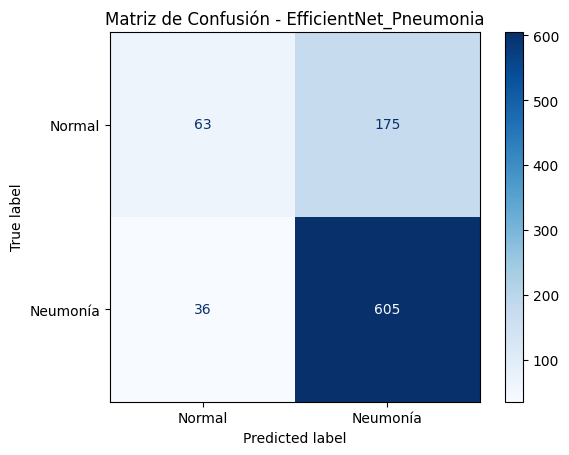

<Figure size 500x500 with 0 Axes>

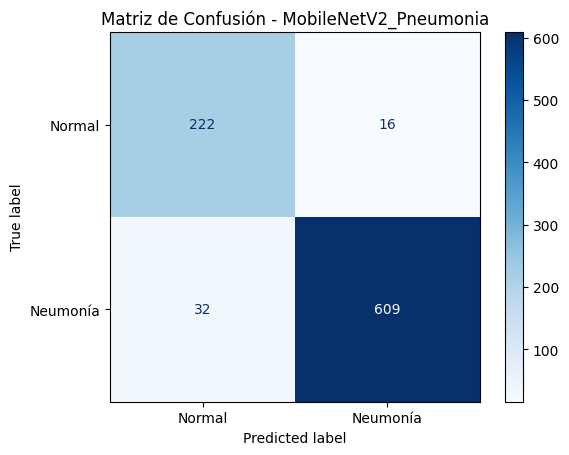

In [31]:

for r in all_results:
    cm = confusion_matrix(r["y_true"], r["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Neumonía"])

    plt.figure(figsize=(5, 5))
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Matriz de Confusión - {r['name']}")
    plt.grid(False)
    plt.show()

### CURVAS ROC

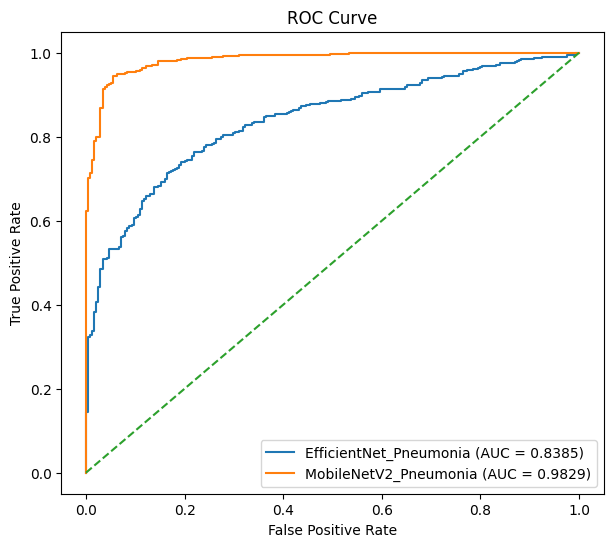

In [32]:
plt.figure(figsize=(7, 6))

for r in all_results:
    fpr, tpr, _ = roc_curve(r["y_true"], r["y_prob"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{r['name']} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### CURVAS PRECISION-RECALL

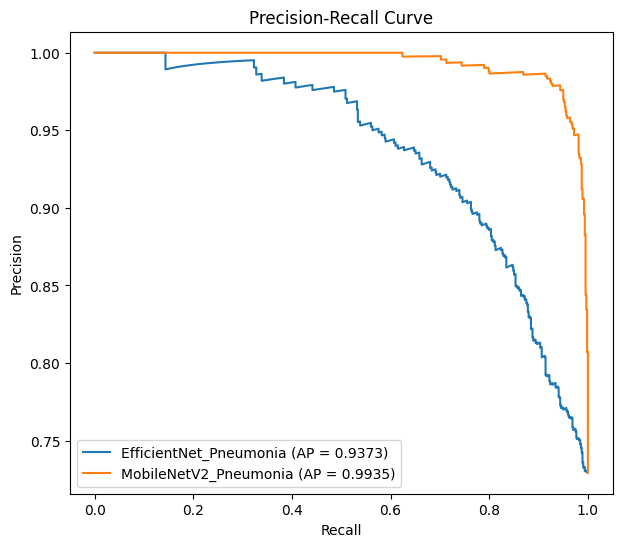

In [33]:
plt.figure(figsize=(7, 6))

for r in all_results:
    precision, recall, _ = precision_recall_curve(r["y_true"], r["y_prob"])
    ap = average_precision_score(r["y_true"], r["y_prob"])
    plt.plot(recall, precision, label=f"{r['name']} (AP = {ap:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

### COMPARACIÓN DE MÉTRICAS

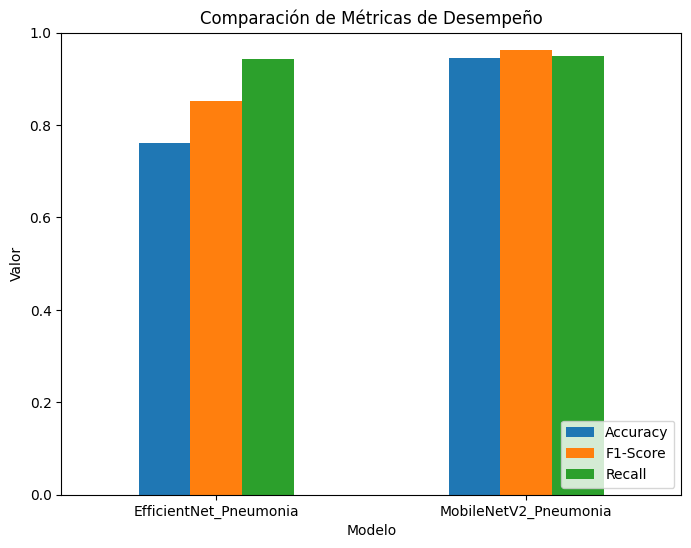

In [34]:
metrics_df = summary_df.set_index("Modelo")[["Accuracy", "F1-Score", "Recall"]]

ax = metrics_df.plot(kind="bar", figsize=(8, 6))
plt.title("Comparación de Métricas de Desempeño")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

### COMPARACIÓN DE EFICIENCIA: TAMAÑO E INFERENCIA

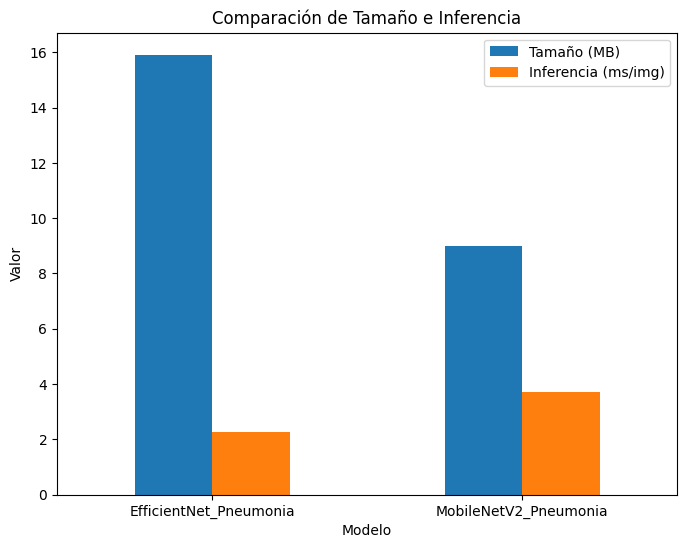

In [35]:
efficiency_df = summary_df.set_index("Modelo")[["Tamaño (MB)", "Inferencia (ms/img)"]]

ax = efficiency_df.plot(kind="bar", figsize=(8, 6))
plt.title("Comparación de Tamaño e Inferencia")
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.show()

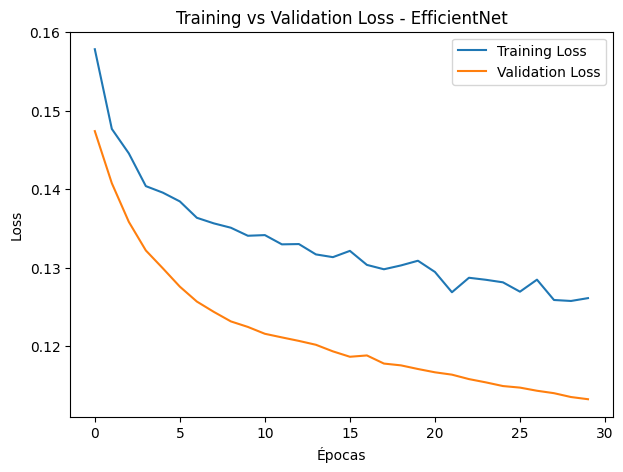

In [37]:
plt.figure(figsize=(7,5))
plt.plot(history_effnet.history["loss"], label="Training Loss")
plt.plot(history_effnet.history["val_loss"], label="Validation Loss")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss - EfficientNet")
plt.legend()
plt.show()

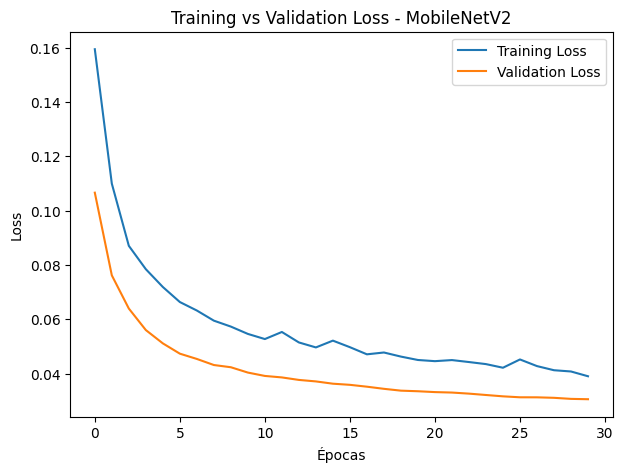

In [38]:
plt.figure(figsize=(7,5))
plt.plot(history_mobilenet.history["loss"], label="Training Loss")
plt.plot(history_mobilenet.history["val_loss"], label="Validation Loss")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss - MobileNetV2")
plt.legend()
plt.show()